## 1. Загрузка данных

### 1.1. Загрузка данных.

In [14]:
import pandas as pd
data_roll = pd.read_csv('lab4_roll.csv')
print(data_roll.head())

   Unnamed: 0  Weight  height
0           0   76.64  151.55
1           1   69.00  190.88
2           2   62.36  144.59
3           3  100.20  191.45
4           4   55.12  149.18


### 1.2. Проверка корректности загрузки.

In [15]:
print(data_roll.describe())
print(data_roll.info())

        Unnamed: 0       Weight       height
count  1374.000000  1374.000000  1374.000000
mean    686.500000    77.916259   170.722271
std     396.783946    13.362495    20.848855
min       0.000000    52.320000   130.070000
25%     343.250000    65.700000   155.780000
50%     686.500000    80.800000   169.865000
75%    1029.750000    86.975000   187.632500
max    1373.000000   103.580000   216.500000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1374 entries, 0 to 1373
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1374 non-null   int64  
 1   Weight      1374 non-null   float64
 2   height      1374 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 32.3 KB
None


### 1.3. Построение диаграммы рассеяния набора данных.

/tmp/ipykernel_1083/470248617.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


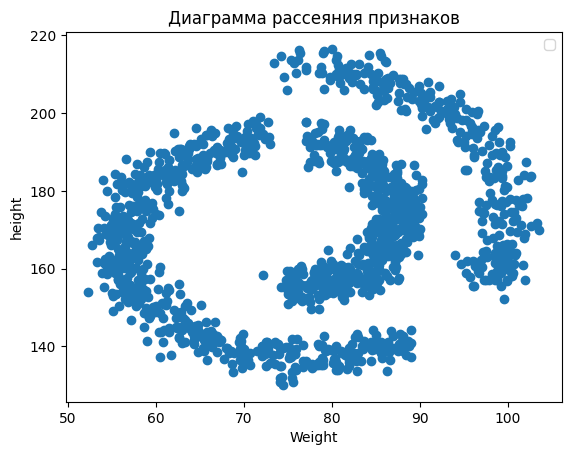

In [16]:
import matplotlib.pyplot as plt

plt.scatter(data_roll['Weight'], data_roll['height'])
plt.xlabel('Weight')
plt.ylabel('height')
plt.title('Диаграмма рассеяния признаков')
plt.legend()
plt.show()

### 1.4. Подготовка набора данных.

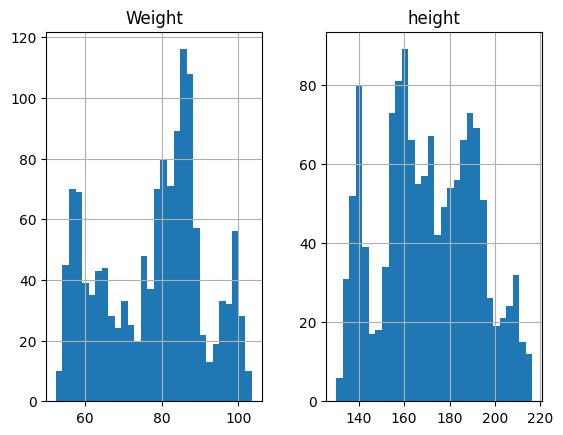

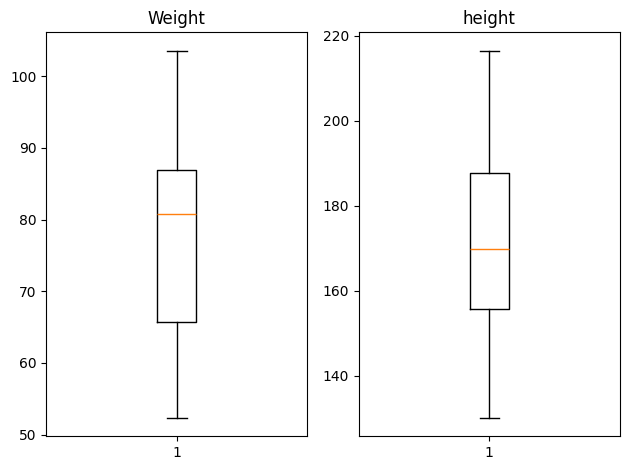

In [17]:
data_roll[['Weight', 'height']].hist(bins=30)
plt.show()

plt.subplot(1,2,1)
plt.boxplot(data_roll['Weight'])
plt.title('Weight')

plt.subplot(1,2,2)
plt.boxplot(data_roll['height'])
plt.title('height')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler

X_role = data_roll[['Weight', 'height']]
print(X_role[:5])

scaler = StandardScaler()
X_role_scaled = scaler.fit_transform(X_role)
X_role_scaled_tf = pd.DataFrame(X_role_scaled, columns=['Weight', 'height'])
print('\n', X_role_scaled_tf.head())
print(X_role_scaled_tf.describe())

   Weight  height
0   76.64  151.55
1   69.00  190.88
2   62.36  144.59
3  100.20  191.45
4   55.12  149.18

      Weight    height
0 -0.095545 -0.919919
1 -0.667503  0.967203
2 -1.164597 -1.253872
3  1.668240  0.994552
4 -1.706609 -1.033635
             Weight        height
count  1.374000e+03  1.374000e+03
mean   3.354910e-16  7.356238e-16
std    1.000364e+00  1.000364e+00
min   -1.916227e+00 -1.950566e+00
25%   -9.145528e-01 -7.169560e-01
50%    2.158871e-01 -4.113333e-02
75%    6.781697e-01  8.113820e-01
max    1.921279e+00  2.196495e+00


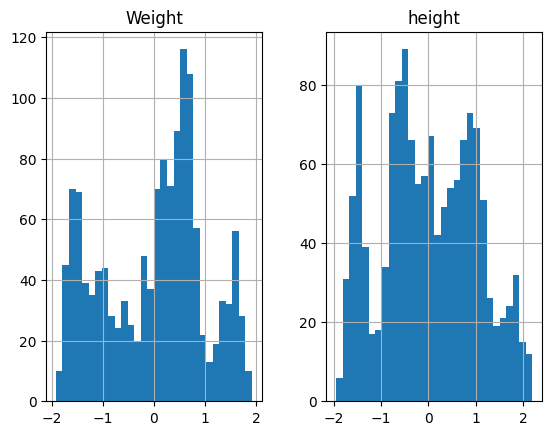

In [19]:
X_role_scaled_tf.hist(bins=30)
plt.show()

## 2. K-Means

### 2.1. Проведение исследования оптимального количества кластеров методов локтя.

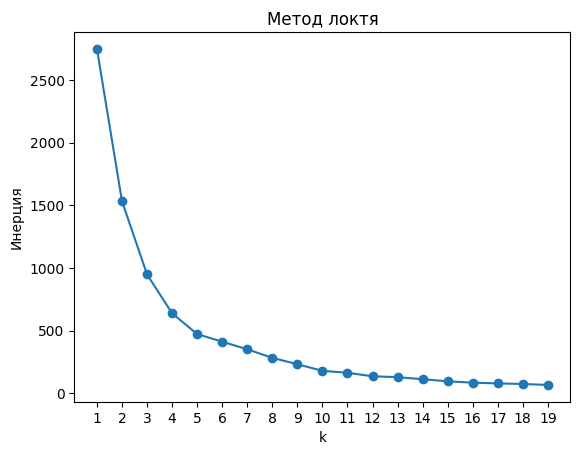

In [20]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 20):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_role_scaled_tf)
    inertia.append(model.inertia_)

plt.plot(range(1, 20), inertia, marker='o')
plt.title("Метод локтя")
plt.xlabel("k")
plt.xticks(range(1, 20))
plt.ylabel("Инерция")
plt.show()

### 2.2. Проведение исследования оптимального количества кластеров методом силуэта.

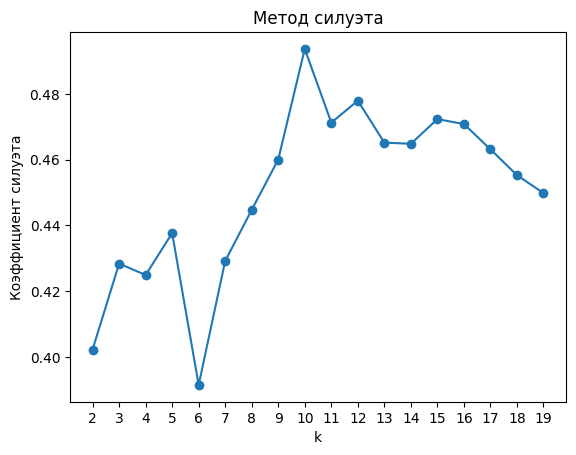

In [21]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 20):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_role_scaled_tf)
    sil_scores.append(silhouette_score(X_role_scaled_tf, labels))

plt.plot(range(2, 20), sil_scores, marker='o')
plt.title("Метод силуэта")
plt.xlabel("k")
plt.xticks(range(2, 20))
plt.ylabel("Коэффициент силуэта")
plt.show()

### 2.3. Проведение кластеризации алгоритмом K-means, с выбранным оптимальным количеством кластеров.
### 2.4. Построение диаграммы рассеяния результатов кластеризации с выделением разным цветом разных кластеров.
k=2-5(метод логтя), k=10 (метод силуэта)

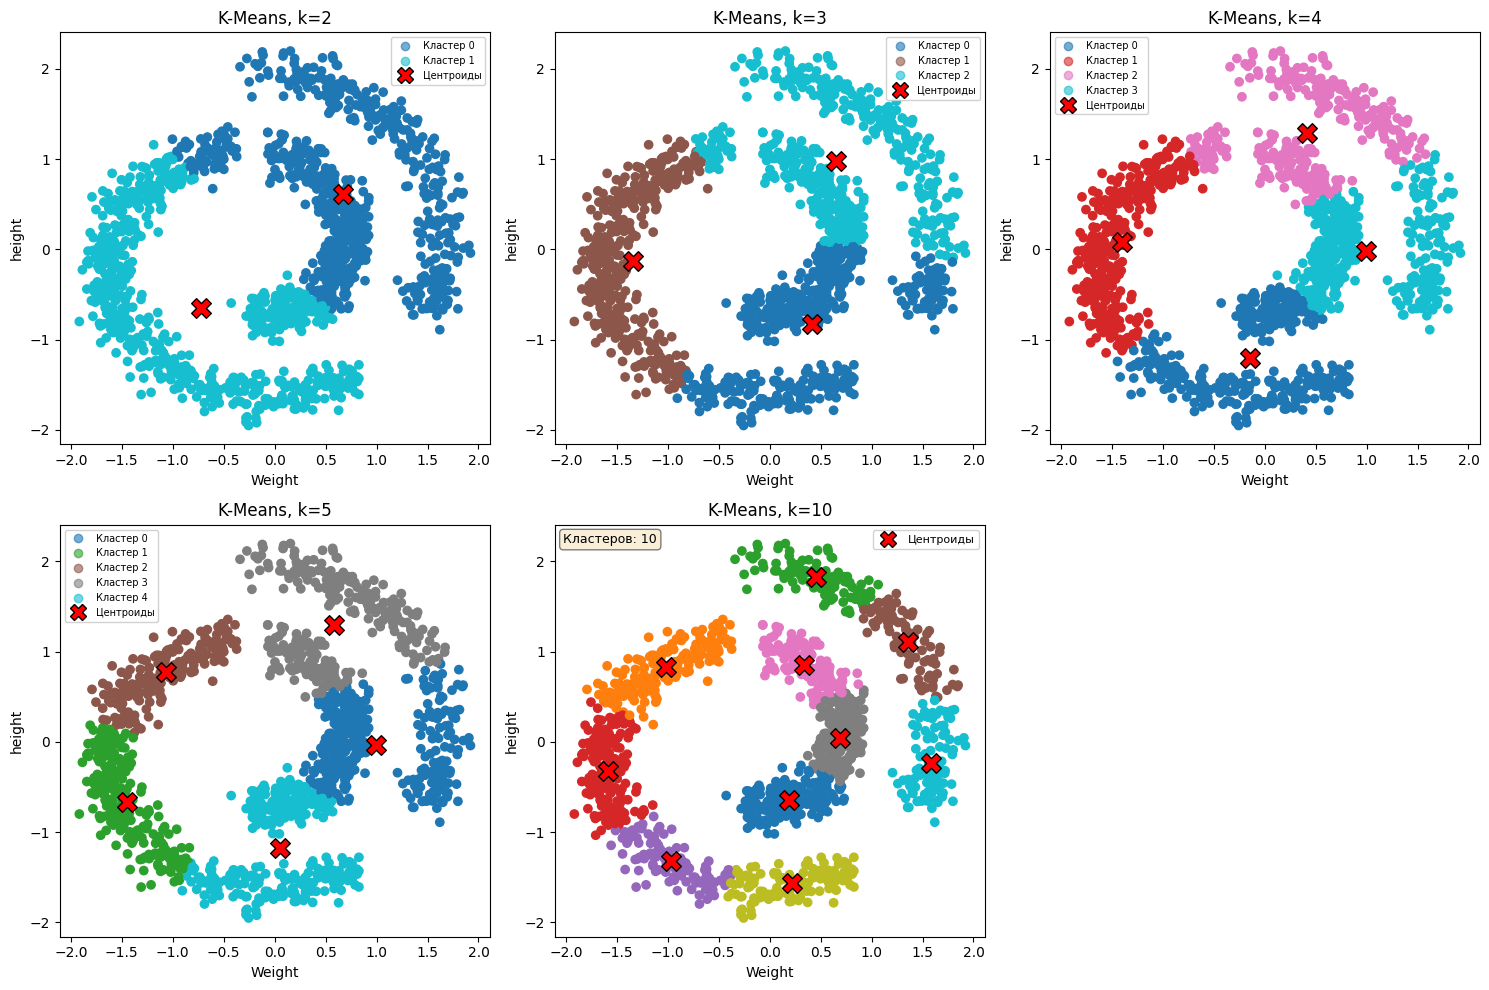

In [22]:
from matplotlib.lines import Line2D

kmeans_models = {}
kmeans_results = {}

k_opt = [2, 3, 4, 5, 10]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, k in enumerate(k_opt): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_role_scaled_tf)
    centroids = kmeans.cluster_centers_
    
    kmeans_models[k] = kmeans
    kmeans_results[k] = {
        'labels': labels,
        'centroids': centroids,
        'inertia': kmeans.inertia_,
        'n_clusters': k
    }
    
    scatter = axes[idx].scatter(X_role_scaled_tf['Weight'], X_role_scaled_tf['height'], c=labels, cmap='tab10')
    axes[idx].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black', label='Центроиды')
    axes[idx].set_title(f'K-Means, k={k}')
    axes[idx].set_xlabel('Weight')
    axes[idx].set_ylabel('height')
    axes[idx].legend()

    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)

    unique_labels = sorted(set(labels))
    labels_legend = []
    for label in unique_labels:
        labels_legend.append(f"Кластер {label}")
    
    centroid_marker = Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markersize=12, markeredgecolor='black', label='Центроиды')
    
    if len(labels_legend) <= 5:
        axes[idx].legend(handles=[*handles, centroid_marker], labels=[*labels_legend, 'Центроиды'], fontsize=7, loc='best', framealpha=0.9)
    else:
        axes[idx].legend([centroid_marker], ['Центроиды'], fontsize=8, loc='upper right', framealpha=0.9)
        axes[idx].text(0.02, 0.98, f'Кластеров: {k}', transform=axes[idx].transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].axis('off')

plt.tight_layout()
plt.show()

### 2.5. Построение диаграмму Вороного для результатов кластеризации.

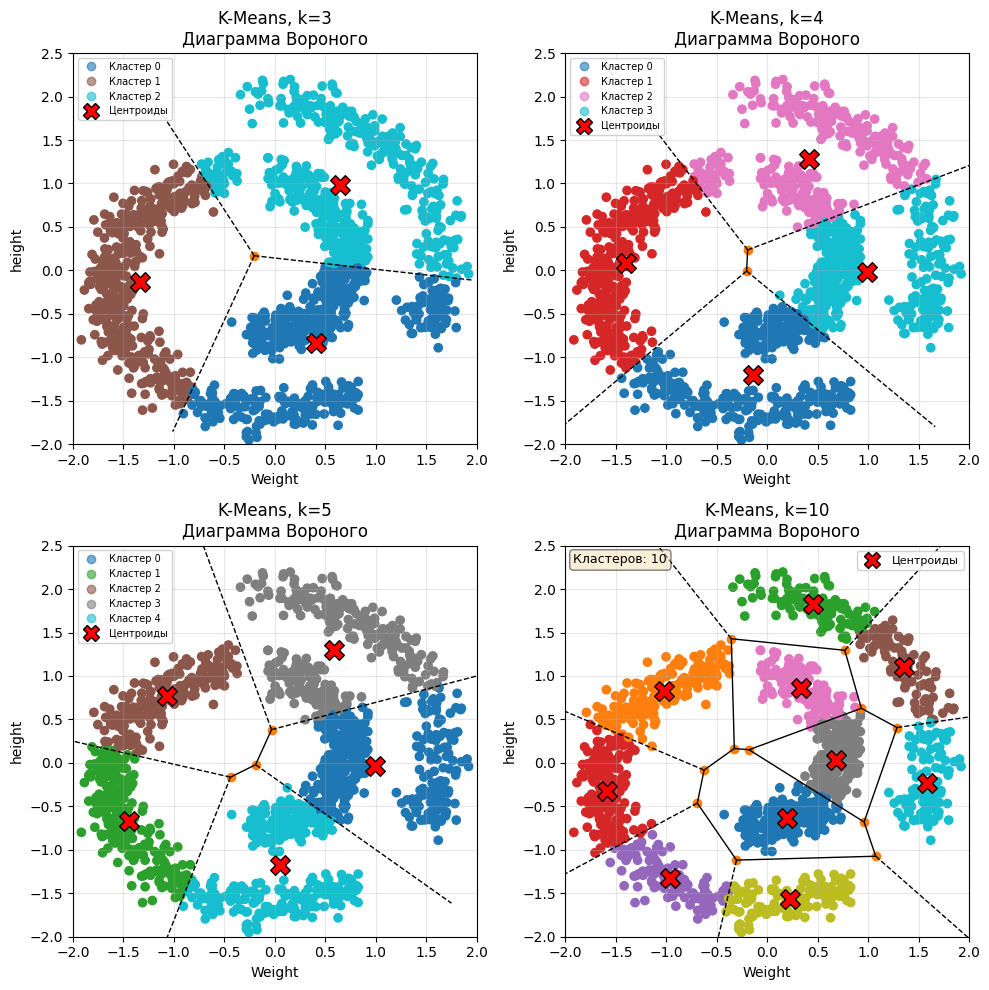

In [23]:
from scipy.spatial import Voronoi, voronoi_plot_2d
import numpy as np


fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

k_opt = [3, 4, 5, 10]

for idx, k in enumerate(k_opt): 
    kmeans = kmeans_models[k]
    labels = kmeans_results[k]['labels']
    centroids = kmeans_results[k]['centroids']
    
    centroids = np.unique(centroids, axis=0)

    vor = Voronoi(centroids)
    voronoi_plot_2d(vor, ax=axes[idx])
    
    scatter = axes[idx].scatter(X_role_scaled[:, 0], X_role_scaled[:, 1], c=labels, cmap='tab10')
    
    axes[idx].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black', zorder=5)
    
    axes[idx].set_title(f'K-Means, k={k}\nДиаграмма Вороного')
    axes[idx].set_xlim(-2, 2)
    axes[idx].set_ylim(-2, 2.5)
    axes[idx].set_xlabel('Weight')
    axes[idx].set_ylabel('height')
    axes[idx].grid(True, alpha=0.3)

    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)

    unique_labels = sorted(set(labels))
    labels_legend = []
    for label in unique_labels:
        labels_legend.append(f"Кластер {label}")
    
    centroid_marker = Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markersize=12, markeredgecolor='black', label='Центроиды')
    
    if len(labels_legend) <= 5:
        axes[idx].legend(handles=[*handles, centroid_marker], labels=[*labels_legend, 'Центроиды'], fontsize=7, loc='best', framealpha=0.9)
    else:
        axes[idx].legend([centroid_marker], ['Центроиды'], fontsize=8, loc='upper right', framealpha=0.9)
        axes[idx].text(0.02, 0.98, f'Кластеров: {k}', transform=axes[idx].transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### 2.6. Выводы о разделении кластеров и успешности применения кластеризации K-means к набору данных.

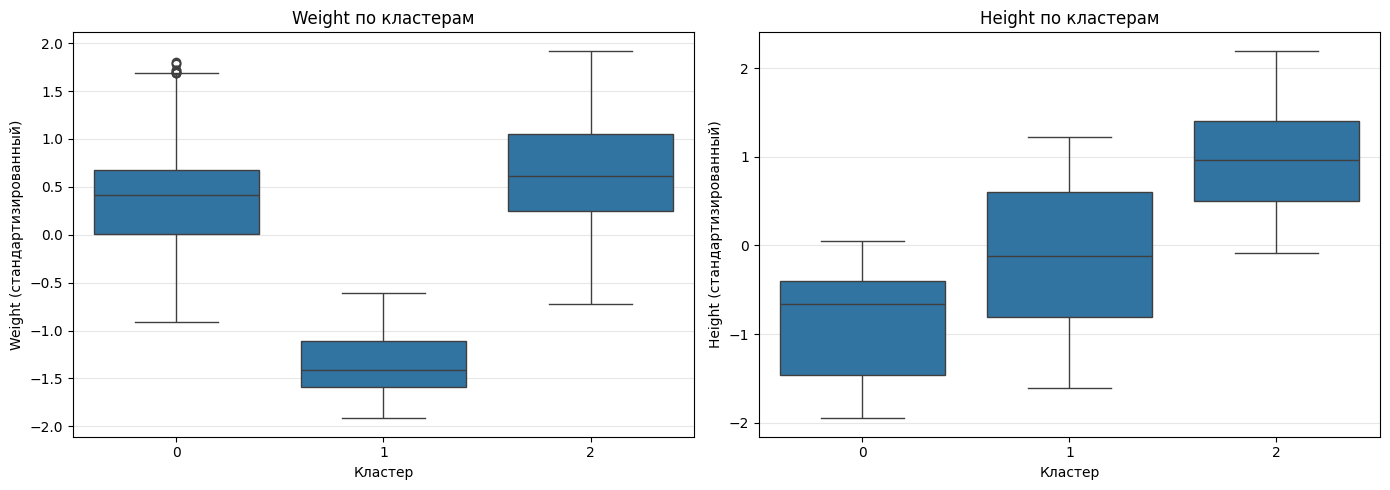

In [24]:
import seaborn as sns

k_opt = 3
labels = kmeans_results[k_opt]['labels']

df_plot = X_role_scaled_tf.copy()
df_plot['cluster'] = labels
df_plot['cluster'] = df_plot['cluster'].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='cluster', y='Weight', data=df_plot, ax=axes[0])
axes[0].set_title('Weight по кластерам')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('Weight (стандартизированный)')
axes[0].grid(alpha=0.3, axis='y')

sns.boxplot(x='cluster', y='height', data=df_plot, ax=axes[1])
axes[1].set_title('Height по кластерам')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Height (стандартизированный)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 2.7. Рассчет количества точек, среднее, СКО, минимум и максимум. Сопоставление результатов с построенными графиками.

In [25]:
df_temp = X_role_scaled_tf.copy()
df_temp['cluster'] = kmeans_results[k_opt]['labels']
pd.set_option('display.width', 1000)

stats = df_temp.groupby('cluster').agg({
    'Weight': ['count', 'mean', 'std', 'min', 'max'],
    'height': ['count', 'mean', 'std', 'min', 'max']
})

print(stats)

        Weight                                         height                                        
         count      mean       std       min       max  count      mean       std       min       max
cluster                                                                                              
0          504  0.406575  0.597008 -0.905569  1.798503    504 -0.835499  0.562757 -1.950566  0.054590
1          387 -1.340188  0.297578 -1.916227 -0.607612    387 -0.128789  0.784261 -1.607977  1.220546
2          483  0.649563  0.608280 -0.724399  1.921279    483  0.975017  0.575932 -0.087916  2.196495


## 3.DBSCAN

### 3.1. Подбор параметров алгоритма DBSCAN.

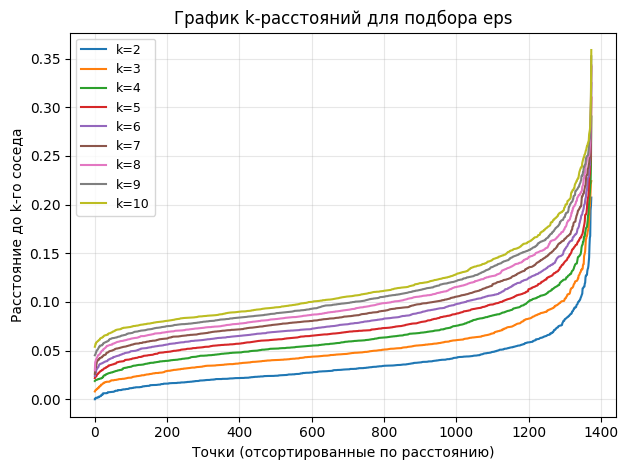

In [26]:
from sklearn.neighbors import NearestNeighbors

for k in range(2, 11):
    neight = NearestNeighbors(n_neighbors=k)
    neight.fit(X_role_scaled_tf)

    distances, _ = neight.kneighbors(X_role_scaled_tf)
    distances = np.sort(distances[:, -1])

    plt.plot(distances, label=f'k={k}')

plt.xlabel('Точки (отсортированные по расстоянию)')
plt.ylabel(f'Расстояние до k-го соседа')
plt.title('График k-расстояний для подбора eps')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

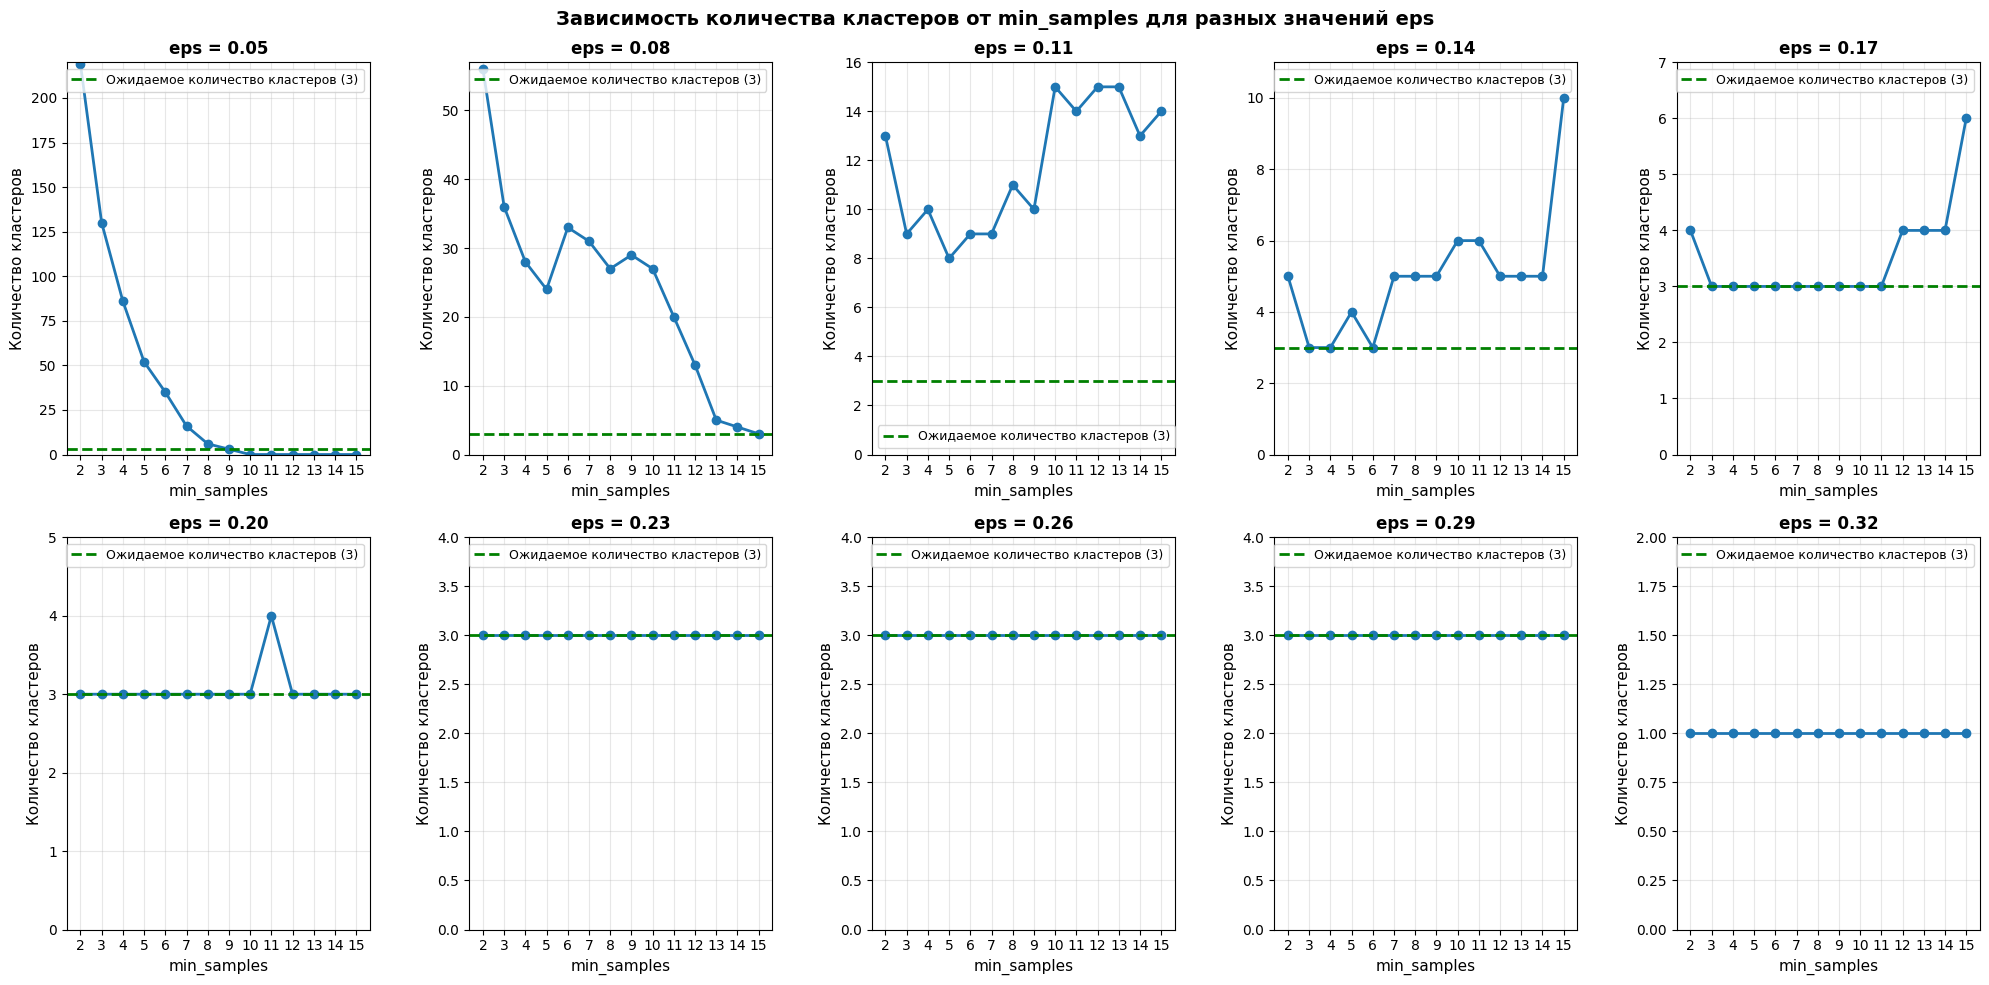

In [27]:
from sklearn.cluster import DBSCAN

eps_values = np.arange(0.05, 0.33, 0.03)
results = {}
min_samples_values = list(range(2, 16))

for min_samp in min_samples_values:
    results[min_samp] = {}
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samp)
        labels = db.fit_predict(X_role_scaled_tf)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)
        results[min_samp][eps] = {'clusters': n_clusters, 'noise': noise}


fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.ravel()

for idx, eps in enumerate(eps_values):
    cluster_values = [results[min_s][eps]['clusters'] for min_s in min_samples_values]
    
    axes[idx].plot(min_samples_values, cluster_values, marker='o', linewidth=2, markersize=6)
    axes[idx].axhline(y=3, color='green', linestyle='--', linewidth=2, label='Ожидаемое количество кластеров (3)')
    axes[idx].set_xlabel('min_samples', fontsize=11)
    axes[idx].set_ylabel('Количество кластеров', fontsize=11)
    axes[idx].set_title(f'eps = {eps:.2f}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xticks(min_samples_values)
    axes[idx].set_ylim(0, max(cluster_values) + 1)
    axes[idx].legend(fontsize=9)
    
plt.suptitle('Зависимость количества кластеров от min_samples для разных значений eps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


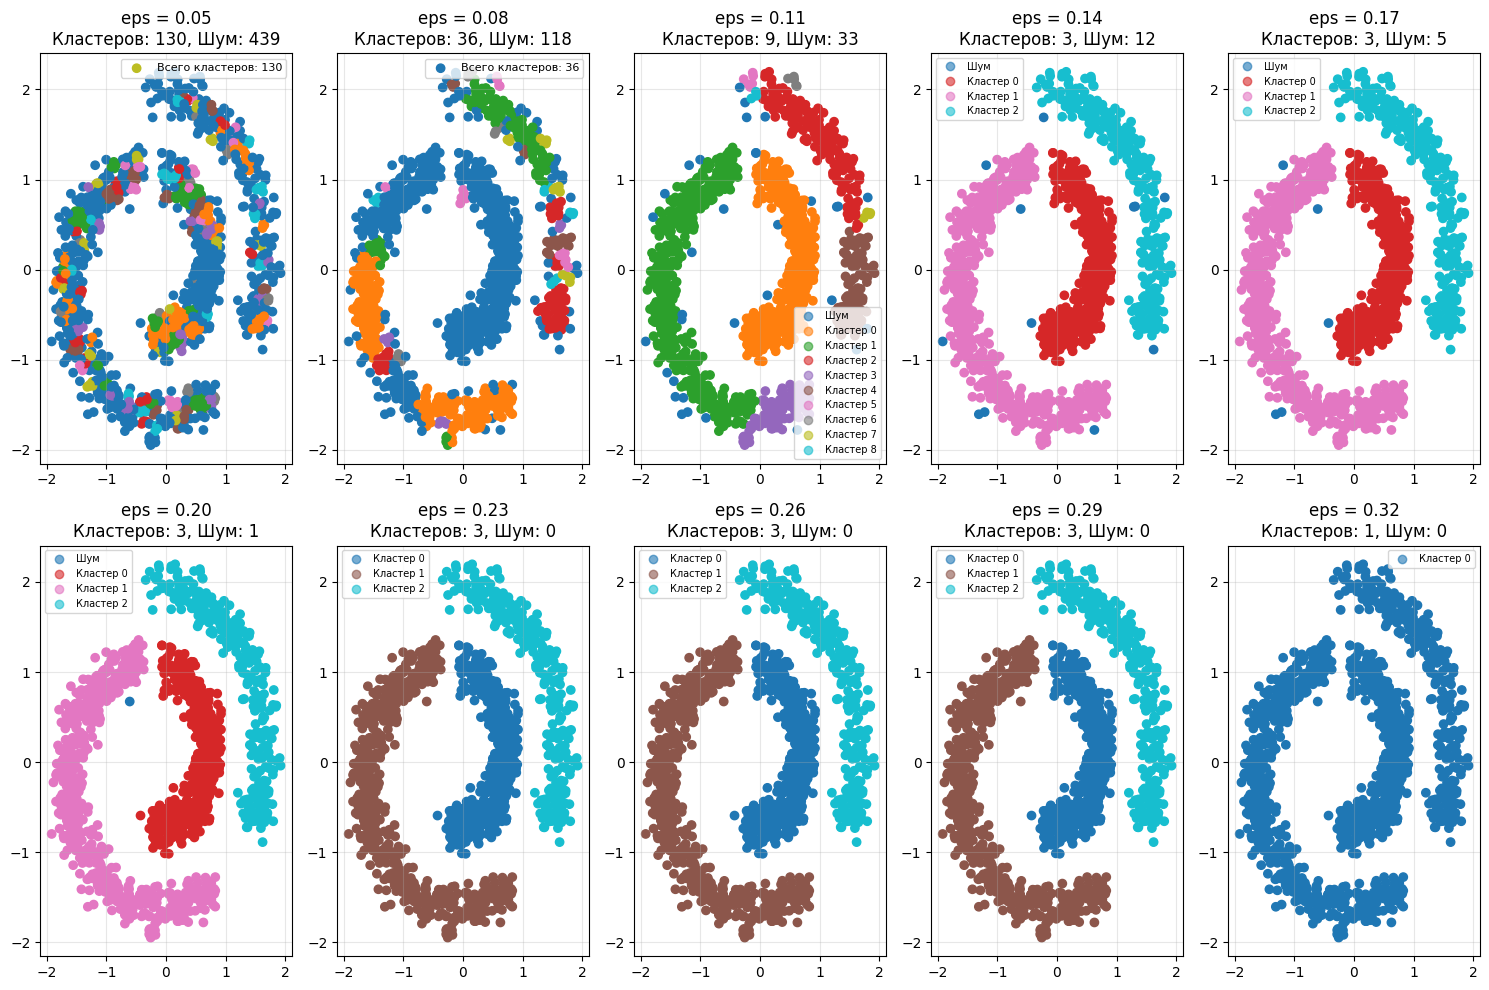

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(15, 10))
axes = axes.ravel()

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=3)
    labels = db.fit_predict(X_role_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    scatter = axes[i].scatter(X_role_scaled[:, 0], X_role_scaled[:, 1], c=labels, cmap='tab10')
    
    axes[i].set_title(f'eps = {eps:.2f}\nКластеров: {n_clusters}, Шум: {n_noise}')
    axes[i].grid(alpha=0.3)
    
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)

    unique_labels = sorted(set(labels))
    labels_legend = []
    for label in unique_labels:
        if label == -1:
            labels_legend.append("Шум")
        else:
            labels_legend.append(f"Кластер {label}")
    
    if len(labels_legend) <= 10:
        axes[i].legend(handles, labels_legend, fontsize=7, loc='best')
    else:
        axes[i].legend([f"Всего кластеров: {n_clusters}"], fontsize=8, loc='upper right')
        
plt.tight_layout()
plt.show()


## 4. Иерархическая кластеризация

### 4.1. Проведение иерархической кластеризацию, подобрав параметр linkage. Построение дендрограммы.

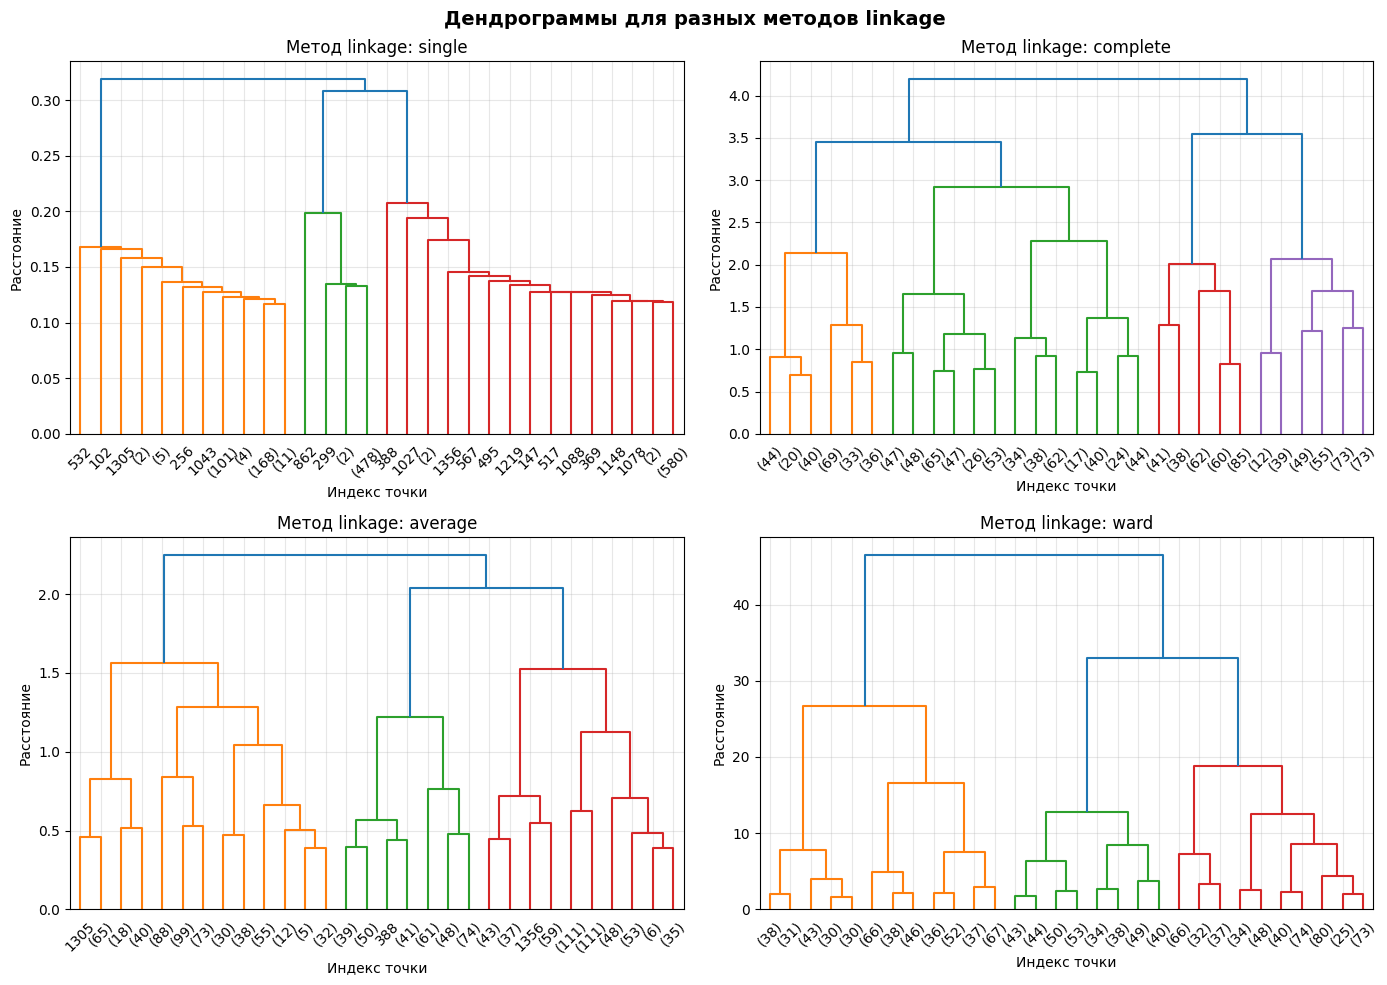

In [29]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, method in enumerate(linkage_methods):
    try:
        Z = linkage(X_role_scaled_tf, method=method)
        dendro_data = dendrogram(Z, no_plot=True)
        
        dendrogram(Z, ax=axes[idx], truncate_mode='lastp', p=30)
        axes[idx].set_title(f'Метод linkage: {method}')
        axes[idx].set_xlabel('Индекс точки')
        axes[idx].set_ylabel('Расстояние')
        axes[idx].grid(alpha=0.3)
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Ошибка:\n{str(e)}', ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'Метод: {method}')

plt.suptitle('Дендрограммы для разных методов linkage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

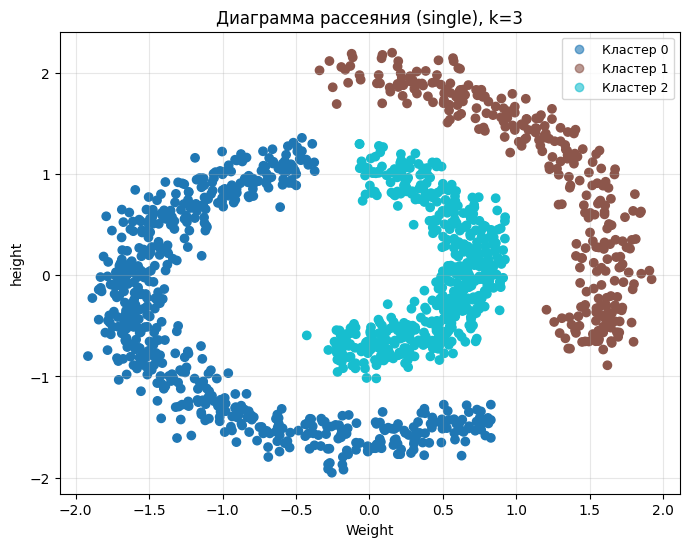

In [30]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='single')
labels = hc.fit_predict(X_role_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_role_scaled_tf.iloc[:, 0], X_role_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')

plt.title(f'Диаграмма рассеяния (single), k=3')
plt.xlabel('Weight')
plt.ylabel('height')
plt.grid(alpha=0.3)
plt.show()

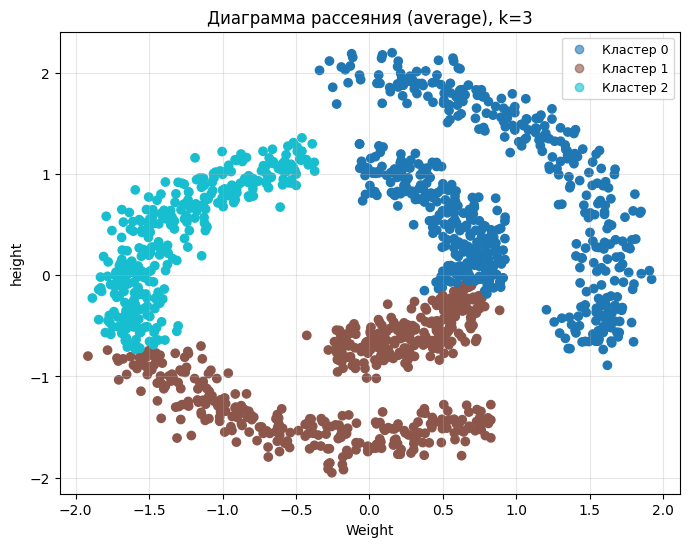

In [31]:
hc = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = hc.fit_predict(X_role_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_role_scaled_tf.iloc[:, 0], X_role_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')
plt.title(f'Диаграмма рассеяния (average), k=3')
plt.xlabel('Weight')
plt.ylabel('height')
plt.grid(alpha=0.3)
plt.show()

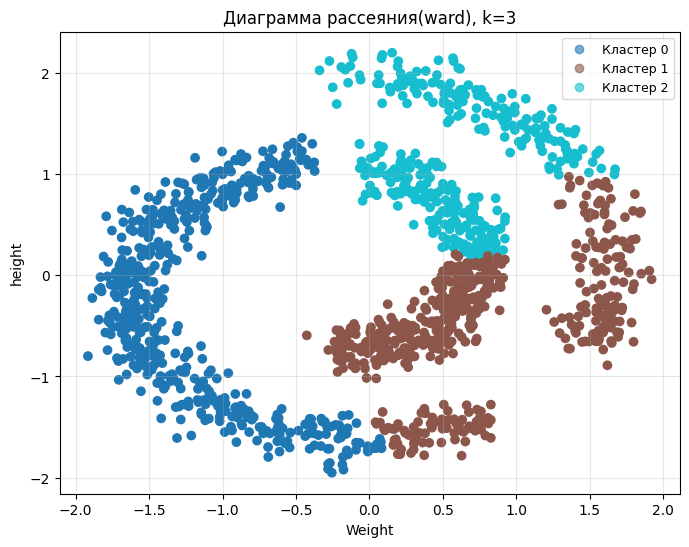

In [32]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = hc.fit_predict(X_role_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_role_scaled_tf.iloc[:, 0], X_role_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')

plt.title(f'Диаграмма рассеяния(ward), k=3')
plt.xlabel('Weight')
plt.ylabel('height')
plt.grid(alpha=0.3)
plt.show()

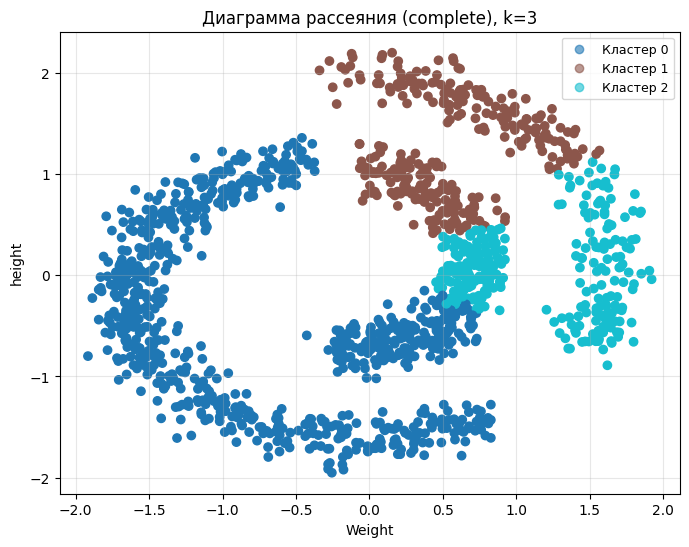

In [33]:
hc = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = hc.fit_predict(X_role_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_role_scaled_tf.iloc[:, 0], X_role_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')
plt.title(f'Диаграмма рассеяния (complete), k=3')
plt.xlabel('Weight')
plt.ylabel('height')
plt.grid(alpha=0.3)
plt.show()

In [34]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster


linkage_methods = ['single', 'complete', 'average', 'ward']
results = {}

for method in linkage_methods:
    Z = linkage(X_role_scaled_tf, method=method)
    labels = fcluster(Z, t=3, criterion='maxclust')
    
    score = silhouette_score(X_role_scaled_tf, labels)
    results[method] = score
    
    print(f'{method}: силуэт = {score:.3f}')

single: силуэт = 0.268
complete: силуэт = 0.287
average: силуэт = 0.424
ward: силуэт = 0.367


In [39]:
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.05, 0.34, 0.01) 
min_samples_values = list(range(2, 5))

best_score = -1
best_params = {}
results = {}

for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_role_scaled_tf)
        
        mask_noise = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = sum(labels == -1)
        
        if n_clusters > 1 and mask_noise.sum() > 0:
            score = silhouette_score(X_role_scaled_tf[mask_noise], labels[mask_noise])
        else:
            score = -1
        
        results[(eps, min_samp)] = {
            'score': score,
            'clusters': n_clusters,
            'noise': n_noise
        }
        
        if score > best_score:
            best_score = score
            best_params = {
                'eps': eps,
                'min_samples': min_samp,
                'clusters': n_clusters,
                'noise': n_noise
            }

print(f"   eps = {best_params['eps']:.2f}")
print(f"   min_samples = {best_params['min_samples']}")
print(f"   Коэффициент силуэта = {best_score:.3f}")
print(f"   Количество кластеров = {best_params['clusters']}")
print(f"   Шумовых точек = {best_params['noise']}")


   eps = 0.05
   min_samples = 4
   Коэффициент силуэта = 0.426
   Количество кластеров = 86
   Шумовых точек = 692


In [40]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_role_scaled_tf)
score_kmeans = silhouette_score(X_role_scaled_tf, labels_kmeans)

dbscan = DBSCAN(eps=0.19, min_samples=15)
labels_dbscan = dbscan.fit_predict(X_role_scaled_tf)

mask_noise = labels_dbscan != -1
X_no_noise = X_role_scaled_tf[mask_noise]
labels_no_noise = labels_dbscan[mask_noise]
score_dbscan = silhouette_score(X_no_noise, labels_no_noise)

hc = AgglomerativeClustering(n_clusters=3, linkage='average')
labels_hc = hc.fit_predict(X_role_scaled_tf)
score_hc = silhouette_score(X_role_scaled_tf, labels_hc)

print(f"K-Means:           {score_kmeans:.3f}")
print(f"DBSCAN:            {score_dbscan:.3f} (без учёта {mask_noise.sum() - len(X_role_scaled_tf)} шумовых точек)")
print(f"Hierarchical (average): {score_hc:.3f}")

K-Means:           0.428
DBSCAN:            0.272 (без учёта -29 шумовых точек)
Hierarchical (average): 0.424
